In [12]:
from __future__ import annotations

from pathlib import Path

import json
import pandas as pd

from utils.utils_read import load_results, _sanitize_answer
from utils.utils_graph import make_balanced_matrix


BASE_PATH = Path(
    "/Users/sebastiancavada/Desktop/tmp_paris/tiny_vqa_creation/output"
)

with open("./utils/metadata.json") as f:
    METADATA = json.load(f)

def _build_eval_df(base_path: Path, run_name: str) -> pd.DataFrame | None:
    run_folder = Path(run_name)
    results_dir = base_path / run_folder / f"results_{run_folder}_sanitized"
    model_cols = sorted(p.stem.replace("_val", "") for p in results_dir.glob("*_val.json"))
    if not model_cols:
        print(f"Skipping {run_name}: no model results in {results_dir}")
        return None

    df = load_results(
        base_path,
        run_folder,
        merge_model_answers=True,
        model_answers_wide=True,
        cache=True,
        add_sim_metadata=True,
    )

    model_cols = [c for c in model_cols if c in df.columns]
    if not model_cols:
        print(f"Skipping {run_name}: no matching model columns in data")
        return None

    df["answer"] = df["answer"].apply(
        lambda a: _sanitize_answer(a, max_prefix_chars=None)
    )

    id_cols = [
        c
        for c in [
            "idx",
            "question_id",
            "category",
            "sub_category",
            "num_objects",
            "object_count",
            "answer",
            "mode_test",
            "mode_val",
            "mode",
        ]
        if c in df.columns
    ]

    eval_df = df.melt(
        id_vars=id_cols,
        value_vars=model_cols,
        var_name="model_id",
        value_name="model_answer",
    )

    valid = eval_df["model_answer"].notna() & eval_df["answer"].notna()
    eval_df["is_correct"] = pd.NA
    eval_df.loc[valid, "is_correct"] = (
        eval_df.loc[valid, "model_answer"] == eval_df.loc[valid, "answer"]
    )

    return eval_df


metadata_map_by_model = {m['id']: m for m in METADATA}

In [13]:
import pandas as pd

base_path = BASE_PATH

run_acc = []

runs = [
    "run_25_roi_ablation_baseline",
    "run_25_roi_circling_no_text",
    "run_25_roi_circling_no_text_layout_position",
    "run_25_roi_circling_text",
    "run_25_roi_circling_text_layout_position",
    "run_25_no_roi_circling_yes_text_layout_position",
    "run_25_no_roi_circling_no_text_layout_position"
]

run_acc = []

for run_name in runs:
    print(f"Processing run: {run_name}")
    run_df = _build_eval_df(base_path, run_name)
    print(run_df) 
        
    if run_df.empty:
        continue

    run_df['run_name'] = run_name
    run_acc.extend(run_df.to_dict('records'))

full_df = pd.DataFrame(run_acc)

Processing run: run_25_roi_ablation_baseline
Cache found at  /Users/sebastiancavada/Desktop/tmp_paris/tiny_vqa_creation/output/run_25_roi_ablation_baseline/merged_results.pkl
Cache is missing required columns: ['object_count', 'visible_pixels_interested_object']
          idx                                        question_id  \
0      3483_i  F_PHYSICS_PROPERTY_YOUNG_MODULUS_OBJECT_HIGH_L...   
1      5545_i                                      F_MASS_OBJECT   
2       727_i  F_PHYSICS_PROPERTY_YOUNG_MODULUS_OBJECT_HIGH_L...   
3      5099_g                  F_PHYSICS_PROPERTY_DENSITY_OBJECT   
4      3096_i                  F_PHYSICS_PROPERTY_DENSITY_OBJECT   
...       ...                                                ...   
45811  3154_g           F_MATERIAL_IDENTIFICATION_OBJECT_LEVEL_1   
45812   272_g            F_PHYSICS_PROPERTY_POISSON_RATIO_OBJECT   
45813  3586_i           F_MATERIAL_IDENTIFICATION_OBJECT_LEVEL_3   
45814  3609_i            F_PHYSICS_PROPERTY_POISSON_RATIO

  0%|          | 0/996 [00:00<?, ?it/s]

FileNotFoundError: [Errno 2] No such file or directory: '/scratch/project/eu-25-92/composite_physics/dataset/simulation_v4/dl3dv/random/8/c-1_no-8_d-10_s-dl3dv-all_models-hf-gso_MLP-10_smooth_h-10-40_seed-74_20251215_163019/simulation_kinematics_min.json'

In [11]:
full_df

NameError: name 'full_df' is not defined

In [5]:
model_num_category_obj_count_acc = full_df.groupby(
    # ["run_name", "model_id", "object_count"]
    ["run_name", "model_id", "sub_category", "object_count"]
).agg(
    model_accuracy=pd.NamedAgg(
        column="is_correct",
        aggfunc=lambda x: x.dropna().mean() * 100  # Accuracy as %
    ),
    total_questions=pd.NamedAgg(
        column="is_correct",
        aggfunc=lambda x: x.dropna().shape[0]
    )
).reset_index()

model_num_category_obj_count_acc_sub_cat = model_num_category_obj_count_acc.groupby(
    ["run_name", "model_id", "object_count"]
).agg(
    macro_accuracy=pd.NamedAgg(
        column="model_accuracy",
        aggfunc=lambda x: x.dropna().mean()
    ),
    total_questions=pd.NamedAgg(
        column="total_questions",
        aggfunc=lambda x: x.dropna().sum()
    )
).reset_index()


model_num_category_obj_count_acc_sub_cat['model_family'] = model_num_category_obj_count_acc_sub_cat['model_id'].apply(lambda mid: metadata_map_by_model[mid]['family'])


model_num_category_obj_count_acc_sub_cat

NameError: name 'full_df' is not defined

NameError: name 'model_num_category_obj_count_acc_sub_cat' is not defined

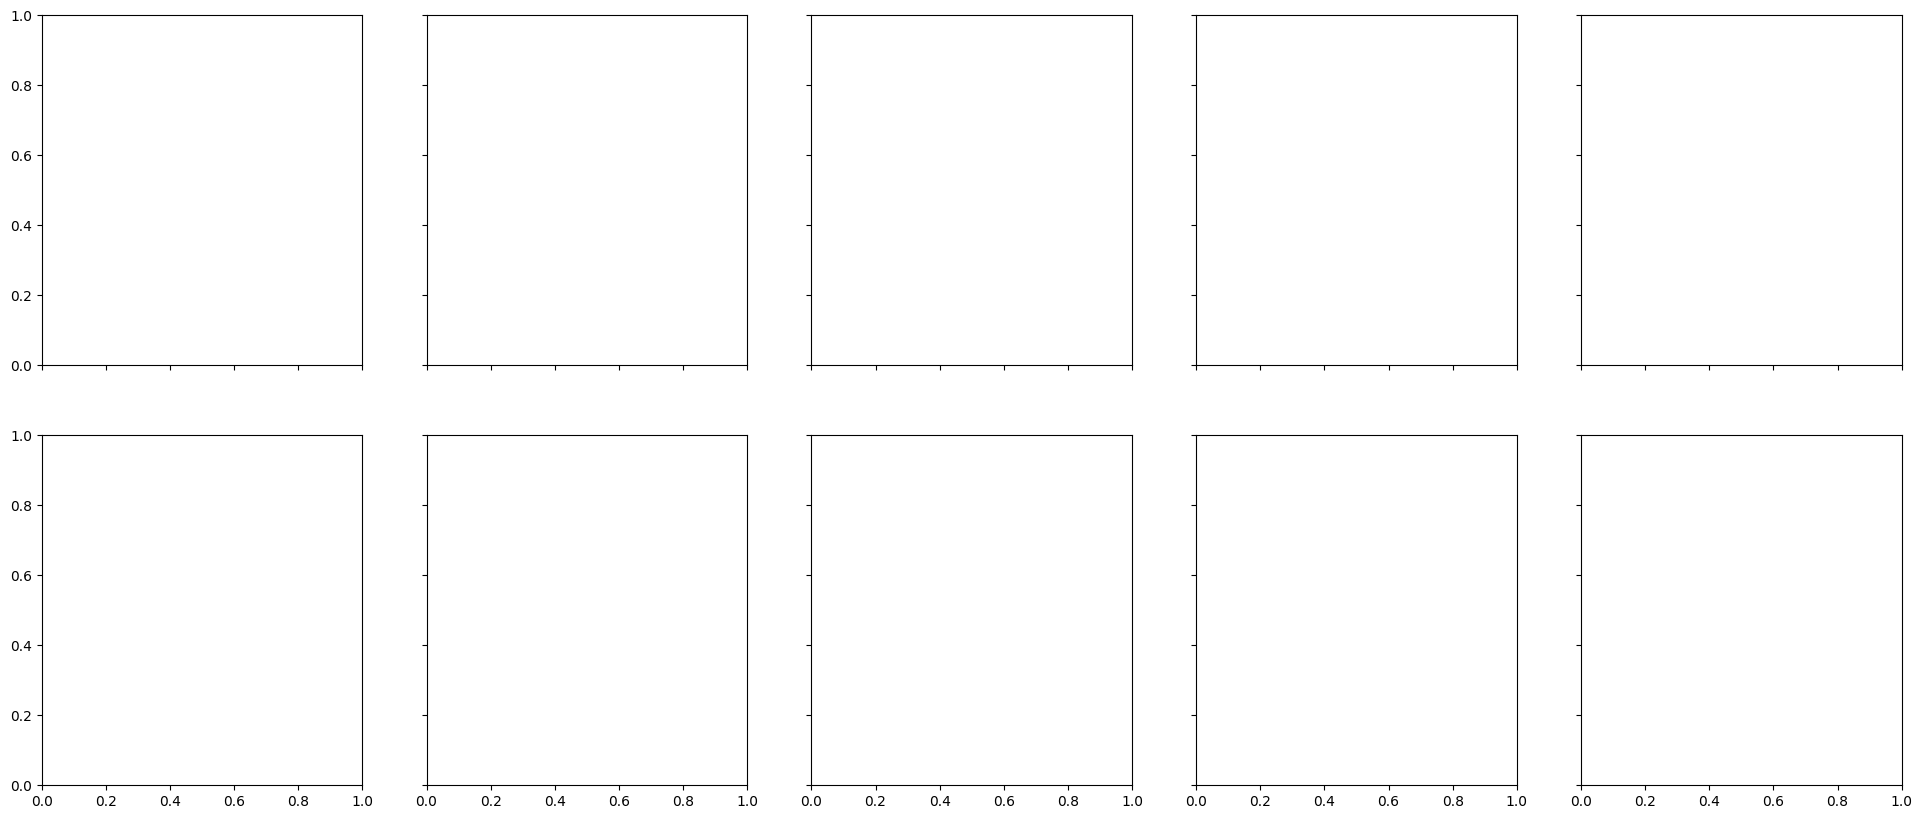

In [6]:
import matplotlib.pyplot as plt

# Setup mapping and order (same as before)
run_map = {
    "run_25_roi_ablation_baseline": "Text",
    "run_25_roi_circling_text": "Text + Circle",
    "run_25_no_roi_circling_yes_text_layout_position": "Text + Layout",
    "run_25_roi_circling_text_layout_position": "Text + Circle + Layout",
    "run_25_roi_circling_no_text_layout_position": "Circle + Layout",
    "run_25_roi_circling_no_text": "Circle",
    "run_25_no_roi_circling_no_text_layout_position": "Layout",
}
run_index = {k: i for i, k in enumerate(run_map.keys())}
model_families = ["InternVLChat2", "LLaVAInterleave", "LLaVAVideo", "Mantis", "Owl3", "Phi", "VILAModel"]

# 1. Create the Figure and Grid
# sharey=True makes comparison easier; sharex=True keeps the layout clean
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(24, 10), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten the 2D grid into a 1D list for easy looping

# Get your specific object counts (assuming there are <= 10)
unique_obj_counts = sorted(model_num_category_obj_count_acc_sub_cat['object_count'].unique())

# 2. Loop through every subplot (axis) and object count
for i, ax in enumerate(axes):
    if i < len(unique_obj_counts):
        obj_num = unique_obj_counts[i]
        
        # Set Title
        ax.set_title(f"Object Count: {obj_num}", fontsize=14, fontweight='bold', pad=10)
        
        # CRITICAL STEP: Filter the main DF for *this specific* object count
        df_subset = model_num_category_obj_count_acc_sub_cat[
            model_num_category_obj_count_acc_sub_cat['object_count'] == obj_num
        ]

        # 3. Plot each Model Family within this subplot
        for model_family in model_families:
            # Filter for family
            family_df = df_subset[df_subset["model_family"] == model_family]
            
            if family_df.empty:
                continue

            # Aggregate: Average across the specific models within this family
            plot_df = (
                family_df.groupby("run_name")["macro_accuracy"]
                .mean()
                .reset_index()
            )
            
            # Map Ordering and Labels
            plot_df["run_idx"] = plot_df["run_name"].map(run_index)
            plot_df = plot_df.sort_values("run_idx")
            plot_df["run_label"] = plot_df["run_name"].map(run_map)

            ax.plot(
                plot_df["run_label"],
                plot_df["macro_accuracy"],
                marker="o",
                linewidth=2,
                markersize=6,
                label=model_family # Label is added here, used later for global legend
            )

        # Formatting
        ax.grid(axis="y", linestyle="--", alpha=0.35)
        # Rotate x-labels (applied to the bottom row automatically by sharex, but we enforce style)
        ax.tick_params(axis='x', rotation=45, labelsize=11)
        
    else:
        # Hide unused subplots if you have fewer than 10 object counts
        ax.axis('off')

# 4. Create a Single Global Legend
# We grab handles/labels from the first subplot (axes[0]) since all plots have the same lines
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='lower center', 
    bbox_to_anchor=(0.5, 0.0), # Positions it at the very bottom
    ncol=len(model_families),  # Spreads it horizontally
    title="Model Family",
    fontsize=12,
    title_fontsize=13,
    frameon=True,
    edgecolor="black"
)

# 5. Final Layout Adjustments
plt.tight_layout()
plt.subplots_adjust(bottom=0.18) # Add extra space at the bottom for the legend
plt.show()

In [156]:
full_df

,idx,question_id,category,sub_category,object_count,answer,mode_test,mode_val,model_id,model_answer,is_correct,run_name
0,3483_i,F_PHYSICS_PROPERTY_YOUNG_MODULUS_OBJECT_HIGH_L...,material_understanding,young_modulus,8,A,image-only,image-only,Aquila-VL-2B,B,False,run_25_roi_ablation_baseline
1,5545_i,F_MASS_OBJECT,material_understanding,mass,10,B,image-only,image-only,Aquila-VL-2B,C,False,run_25_roi_ablation_baseline
2,727_i,F_PHYSICS_PROPERTY_YOUNG_MODULUS_OBJECT_HIGH_L...,material_understanding,young_modulus,3,C,image-only,image-only,Aquila-VL-2B,B,False,run_25_roi_ablation_baseline
3,5099_g,F_PHYSICS_PROPERTY_DENSITY_OBJECT,material_understanding,density,10,A,general,general,Aquila-VL-2B,NaN,None,run_25_roi_ablation_baseline
4,3096_i,F_PHYSICS_PROPERTY_DENSITY_OBJECT,material_understanding,density,7,C,image-only,image-only,Aquila-VL-2B,A,False,run_25_roi_ablation_baseline
...,...,...,...,...,...,...,...,...,...,...,...,...
328675,3154_g,F_MATERIAL_IDENTIFICATION_OBJECT_LEVEL_1,material_understanding,material_identification,7,D,general,general,vila-1.5-8b,A,False,run_25_no_roi_circling_no_text_layout_position
328676,272_g,F_PHYSICS_PROPERTY_POISSON_RATIO_OBJECT,material_understanding,poisson_ratio,2,A,general,general,vila-1.5-8b,A,True,run_25_no_roi_circling_no_text_layout_position
328677,3586_i,F_MATERIAL_IDENTIFICATION_OBJECT_LEVEL_3,material_understanding,material_identification,8,B,image-only,image-only,vila-1.5-8b,A,False,run_25_no_roi_circling_no_text_layout_position
328678,3609_i,F_PHYSICS_PROPERTY_POISSON_RATIO_OBJECT,material_understanding,poisson_ratio,8,A,image-only,image-only,vila-1.5-8b,A,True,run_25_no_roi_circling_no_text_layout_position


In [ ]:
full_df_filtered = full_df[full_df['object_count'] >= 5]

model_num_category_acc = full_df_filtered.groupby(
    # ["run_name", "model_id", "object_count"]
    ["run_name", "model_id", "sub_category"]
).agg(
    model_accuracy=pd.NamedAgg(
        column="is_correct",
        aggfunc=lambda x: x.mean() * 100  # Accuracy as %
    ),
    total_questions=pd.NamedAgg(
        column="is_correct",
        aggfunc=lambda x: x.dropna().shape[0]
    )
).reset_index()

show = model_num_category_acc[(model_num_category_acc['run_name'] == 'run_25_roi_ablation_baseline') & (model_num_category_acc['model_id'] == 'Aquila-VL-2B')]
show



,run_name,model_id,sub_category,model_accuracy,total_questions
480,run_25_roi_ablation_baseline,Aquila-VL-2B,density,6.250000,64
481,run_25_roi_ablation_baseline,Aquila-VL-2B,mass,38.095238,63
482,run_25_roi_ablation_baseline,Aquila-VL-2B,material_identification,43.939394,66
483,run_25_roi_ablation_baseline,Aquila-VL-2B,poisson_ratio,47.619048,63
484,run_25_roi_ablation_baseline,Aquila-VL-2B,young_modulus,38.461538,65


In [179]:
model_num_category_obj_sub_cat = model_num_category_acc.groupby(
    ["run_name", "model_id",]
).agg(
    macro_accuracy=pd.NamedAgg(
        column="model_accuracy",
        aggfunc=lambda x: x.dropna().mean()
    ),
    total_questions=pd.NamedAgg(
        column="total_questions",
        aggfunc=lambda x: x.dropna().sum()
    )
).reset_index()


model_num_category_obj_sub_cat['model_family'] = model_num_category_obj_sub_cat['model_id'].apply(lambda mid: metadata_map_by_model[mid]['family'])

show = model_num_category_obj_sub_cat[(model_num_category_obj_sub_cat['run_name'] == 'run_25_roi_ablation_baseline') & (model_num_category_obj_sub_cat['model_family'] == 'LLaVAVideo')]
show

,run_name,model_id,macro_accuracy,total_questions,model_family
106,run_25_roi_ablation_baseline,LLaVA-NeXT-Video-7B-DPO-hf,24.318267,595,LLaVAVideo
107,run_25_roi_ablation_baseline,LLaVA-NeXT-Video-7B-hf,25.082611,597,LLaVAVideo


In [182]:
model_num_category_obj_sub_cat_family = model_num_category_obj_sub_cat.groupby(
    ["run_name", "model_family",]
).agg(
    family_accuracy=pd.NamedAgg(
        column="macro_accuracy",
        aggfunc=lambda x: x.dropna().mean()
    ),
    total_questions=pd.NamedAgg(
        column="total_questions",
        aggfunc=lambda x: x.dropna().sum()
    )
).reset_index()


model_num_category_obj_sub_cat_family
show = model_num_category_obj_sub_cat_family[(model_num_category_obj_sub_cat_family['run_name'] == 'run_25_roi_ablation_baseline') & (model_num_category_obj_sub_cat_family['model_family'] == 'LLaVAVideo')]
show

,run_name,model_family,family_accuracy,total_questions
47,run_25_roi_ablation_baseline,LLaVAVideo,24.700439,1192


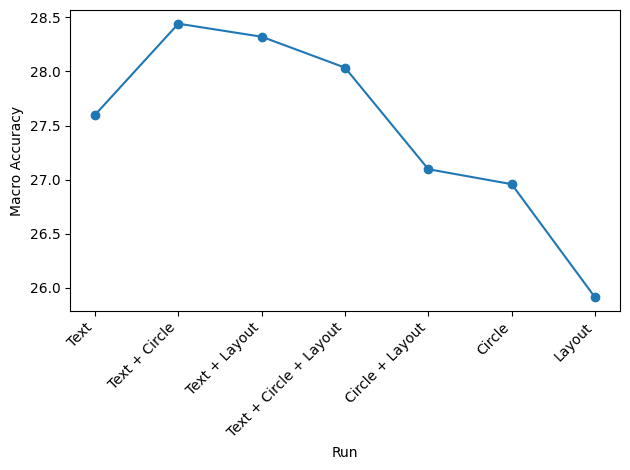

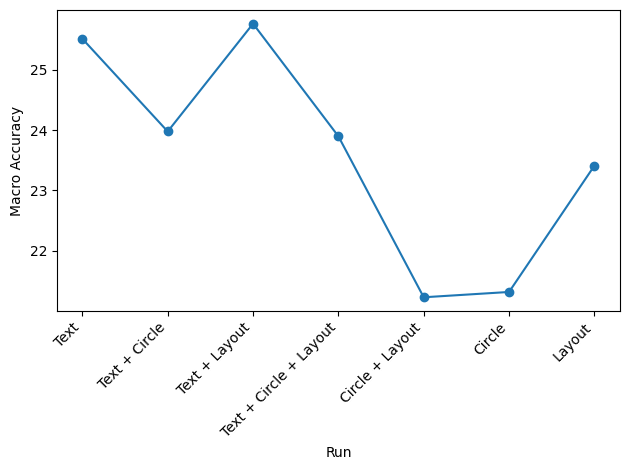

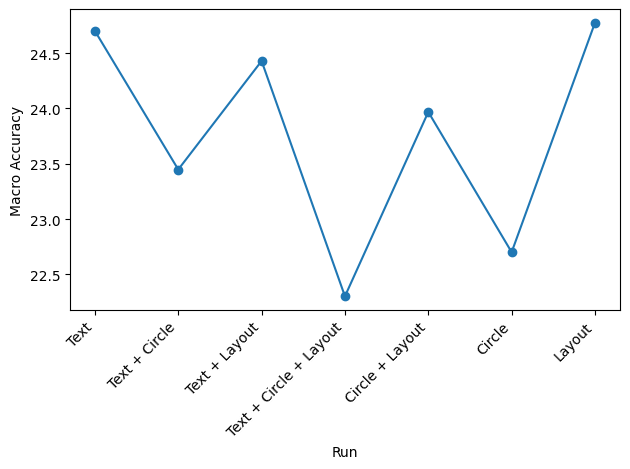

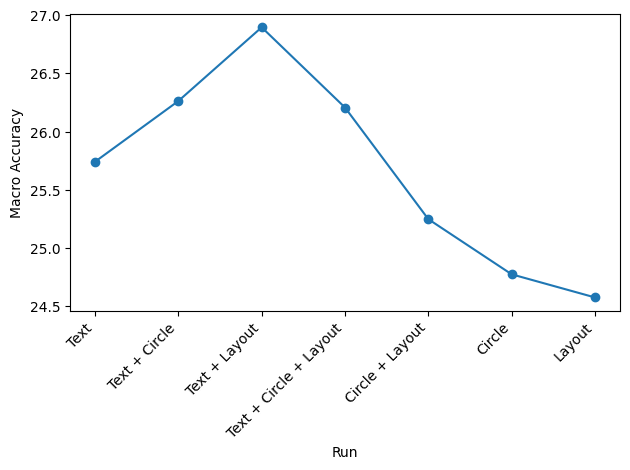

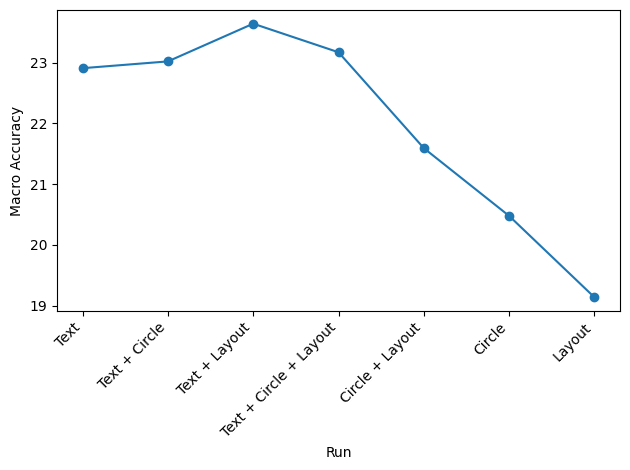

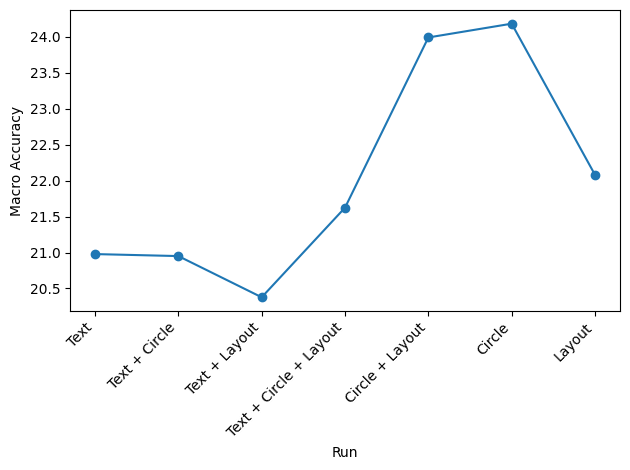

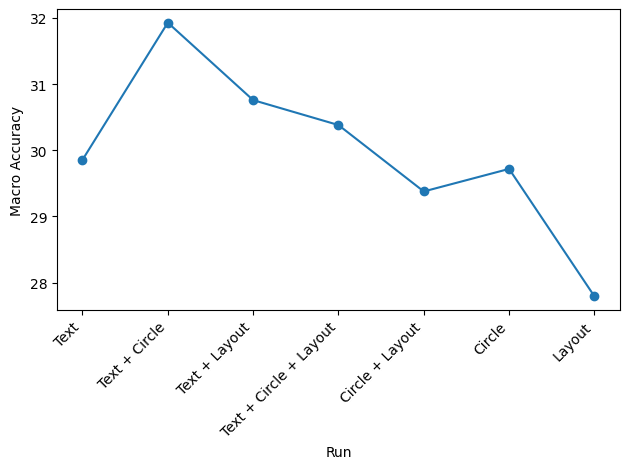

In [184]:
import matplotlib.pyplot as plt

run_map = {    
    "run_25_roi_ablation_baseline": "Text",
    "run_25_roi_circling_text": "Text + Circle",
    "run_25_no_roi_circling_yes_text_layout_position": "Text + Layout",    
    "run_25_roi_circling_text_layout_position": "Text + Circle + Layout",          
    "run_25_roi_circling_no_text_layout_position": "Circle + Layout",
    "run_25_roi_circling_no_text": "Circle",
    "run_25_no_roi_circling_no_text_layout_position": "Layout",  
}

run_index = {k: i for i, k in enumerate(run_map.keys())}

for model_family in ["InternVLChat2", "LLaVAInterleave", "LLaVAVideo", "Mantis", "Owl3", "Phi", "VILAModel"]:
    family_df = model_num_category_obj_sub_cat_family[model_num_category_obj_sub_cat_family['model_family'] == model_family].groupby("run_name")["family_accuracy"].mean().reset_index()


    family_df["run_idx"] = family_df["run_name"].map(run_index)
    family_df = family_df.sort_values("run_idx")
    family_df["run_label"] = family_df["run_name"].map(run_map)    

    # print(family_df)
    plt.figure()
    plt.plot(family_df["run_label"], family_df["family_accuracy"], marker="o")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Macro Accuracy")
    plt.xlabel("Run")
    plt.tight_layout()
    plt.show()

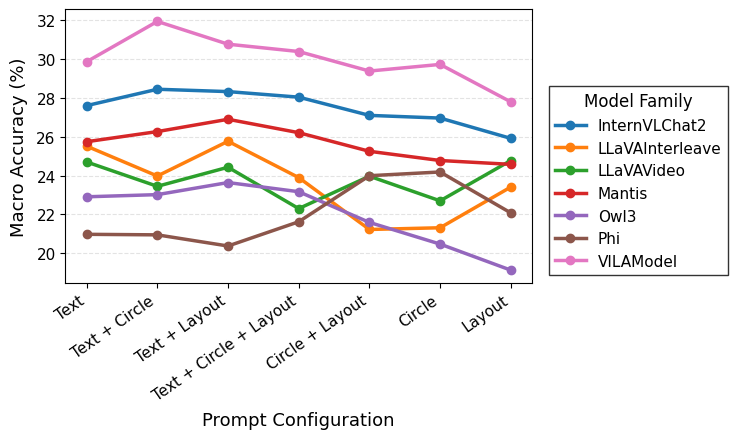

In [ ]:
import matplotlib.pyplot as plt

run_map = {    
    "run_25_roi_ablation_baseline": "Text",
    "run_25_roi_circling_text": "Text + Circle",
    "run_25_no_roi_circling_yes_text_layout_position": "Text + Layout",    
    "run_25_roi_circling_text_layout_position": "Text + Circle + Layout",          
    "run_25_roi_circling_no_text_layout_position": "Circle + Layout",
    "run_25_roi_circling_no_text": "Circle",
    "run_25_no_roi_circling_no_text_layout_position": "Layout",  
}

run_index = {k: i for i, k in enumerate(run_map.keys())}

plt.figure(figsize=(7.5, 4.5))

plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.grid(axis="x", visible=False)

for model_family in ["InternVLChat2", "LLaVAInterleave", "LLaVAVideo",
                     "Mantis", "Owl3", "Phi", "VILAModel"]:        

    family_df = (
        model_num_category_obj_sub_cat[model_num_category_obj_sub_cat["model_family"] == model_family]
        .groupby("run_name")["macro_accuracy"]
        .mean()
        .reset_index()
    )

    family_df["run_idx"] = family_df["run_name"].map(run_index)
    family_df = family_df.sort_values("run_idx")
    family_df["run_label"] = family_df["run_name"].map(run_map)

    plt.plot(
        family_df["run_label"],
        family_df["macro_accuracy"],
        marker="o",
        linewidth=2.5,
        markersize=6,
        label=model_family,
    )

plt.xticks(rotation=35, ha="right", fontsize=11)
plt.yticks(fontsize=11)

plt.xlabel("Prompt Configuration", fontsize=13, labelpad=6)
plt.ylabel("Macro Accuracy (%)", fontsize=13, labelpad=6)

plt.legend(
    title="Model Family",
    title_fontsize=12,
    fontsize=11,
    loc="lower left",
    bbox_to_anchor=(1.02, 0.0, 0.3, 1.0),  # ← full height
    bbox_transform=plt.gca().transAxes,
    frameon=True,
    fancybox=False,
    edgecolor="black",
)

plt.tight_layout()
plt.show()


In [163]:
import matplotlib.pyplot as plt

run_map = {    
    "run_25_roi_ablation_baseline": "Text",
    "run_25_roi_circling_text": "Text + Circle",
    "run_25_no_roi_circling_yes_text_layout_position": "Text + Layout",    
    "run_25_roi_circling_text_layout_position": "Text + Circle + Layout",          
    "run_25_roi_circling_no_text_layout_position": "Circle + Layout",
    "run_25_roi_circling_no_text": "Circle",
    "run_25_no_roi_circling_no_text_layout_position": "Layout",  
}

run_index = {k: i for i, k in enumerate(run_map.keys())}

for model_family in ["InternVLChat2", "LLaVAInterleave", "LLaVAVideo", "Mantis", "Owl3", "Phi", "VILAModel"]:
    family_df = plot_df[plot_df['model_family'] == model_family].groupby("run")["model_accuracy"].mean().reset_index()


    family_df["run_idx"] = family_df["run"].map(run_index)
    family_df = family_df.sort_values("run_idx")
    family_df["run_label"] = family_df["run"].map(run_map)    

    # print(family_df)
    plt.figure()
    plt.plot(family_df["run_label"], family_df["model_accuracy"], marker="o")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Macro Accuracy")
    plt.xlabel("Run")
    plt.tight_layout()
    plt.show()

KeyError: 'model_family'